In [10]:
from LightGlue.lightglue import LightGlue, SuperPoint, DISK
from LightGlue.lightglue.utils import  rbd
from LightGlue.lightglue import viz2d
import numpy as np
import torch
import cv2
import os
import matplotlib.pyplot as plt

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 'mps', 'cpu'

extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(features="superpoint").eval().to(device)

In [9]:
dir = '/media/system/ZERBUIS_EXT_STOR/temp/exp/src/internvl_finetuning/3d-vlm-gd/arkitscenes/raw/Training/40753679/lowres_wide'
file_names = sorted([os.path.join(dir, f) for f in os.listdir(dir)])
# file_names

In [21]:
def load_image(path):
    image = cv2.imread(path, 0)
    image = image/255.0
    image = torch.from_numpy(image).unsqueeze(0).float()
    return image

image0, image1 = load_image(file_names[0]), load_image(file_names[1])
# plt.subplot(1, 2, 1)
# plt.imshow(image0, cmap='gray')
# plt.subplot(1, 2, 2)
# plt.imshow(image1, cmap='gray')

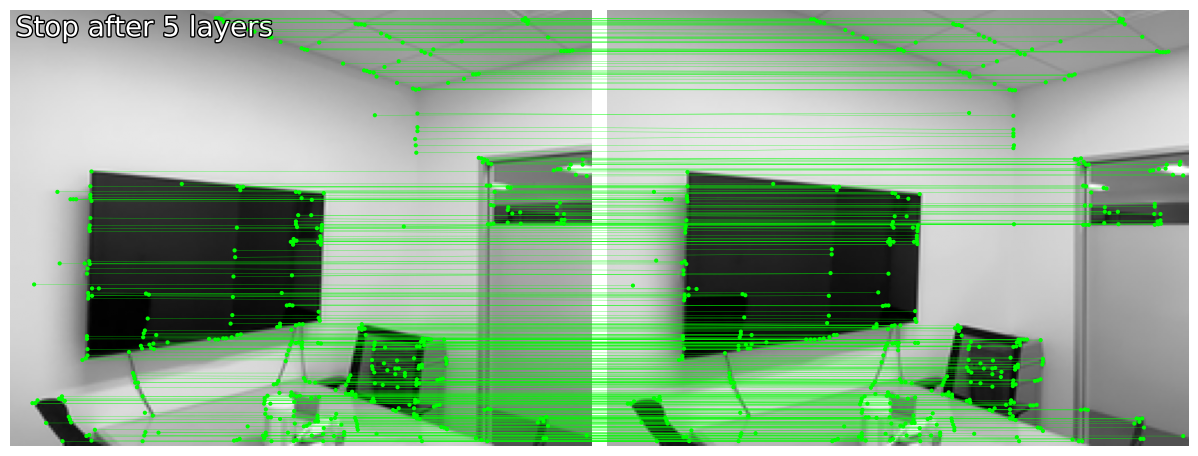

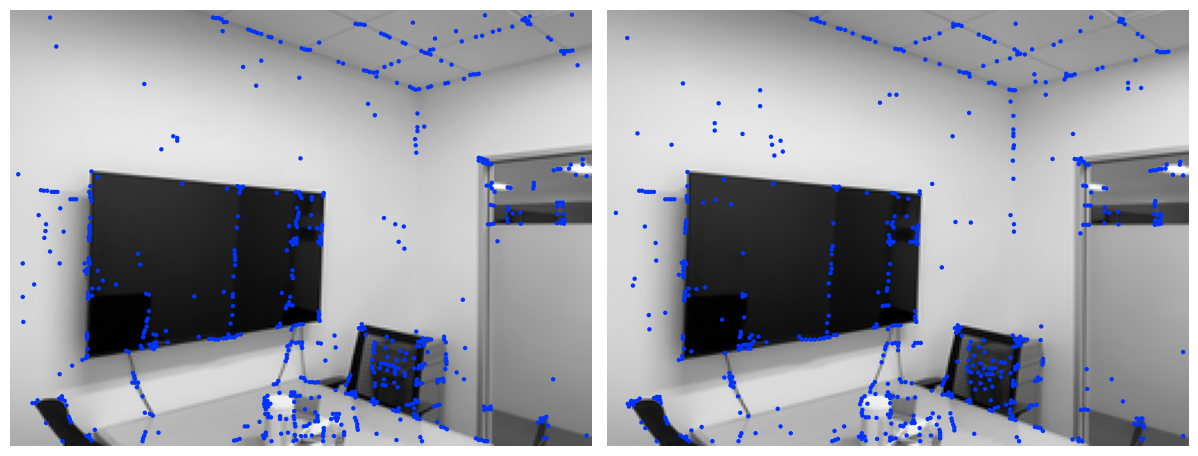

In [22]:
feats0 = extractor.extract(image0.to(device))
feats1 = extractor.extract(image1.to(device))
matches01 = matcher({"image0": feats0, "image1": feats1})
feats0, feats1, matches01 = [
    rbd(x) for x in [feats0, feats1, matches01]
]  # remove batch dimension

kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers', fs=20)

kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=10)

In [28]:
kpts1

tensor([[212.8750,   2.8750],
        [ 92.1250,   3.1250],
        [225.6250,   3.3750],
        ...,
        [181.1250, 189.3750],
        [207.3750, 189.3750],
        [208.8750, 189.3750]], device='cuda:0')

In [27]:
kpts0.shape, kpts1.shape

(torch.Size([641, 2]), torch.Size([608, 2]))

In [42]:
kptls_1 = [np.array(kpts0[i[0]].cpu()) for i in matches]
kptls_2 = [np.array(kpts0[i[1]].cpu()) for i in matches]
kptls_2[0]

/tmp/ipykernel_78607/1949303059.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  kptls_1 = [np.array(kpts0[i[0]].cpu()) for i in matches]
/tmp/ipykernel_78607/1949303059.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  kptls_2 = [np.array(kpts0[i[1]].cpu()) for i in matches]


array([17.125,  2.875], dtype=float32)